In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/chest_xray.zip"

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive (4).zip'
extract_path = '/content/chest_xray'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


print(os.listdir(extract_path))

['chest_xray']


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['IMG_20250211_194612.jpg',
 'Screenshot_2025-03-11-13-43-32-697_com.phonepe.app.jpg',
 'Screenshot_2025-03-13-15-40-16-126_com.phonepe.app.jpg',
 'IMG-20230919-WA0017.jpg',
 'Screenshot_2024-08-12-15-35-22-640_com.google.android.apps.nbu.paisa.user.jpg',
 'IMG-20240913-WA0003.jpg',
 'Screenshot_2024-09-18-16-02-09-614_com.phonepe.app.jpg',
 'Screenshot_2024-09-27-09-28-16-320_com.phonepe.app.jpg',
 'Colab Notebooks',
 'Universe (1).docx',
 'Universe.docx',
 'Untitled16.ipynb',
 'exp18.ipynb',
 'Exp_11.ipynb',
 'Untitled11_2.ipynb',
 'ExP_4.ipynb',
 'Exp4_2.ipynb',
 'Exp_9.ipynb',
 'Exp 16(2).ipynb',
 'Exp 16(1).ipynb',
 'Ex16.3.ipynb',
 'Exp1.ipynb',
 'Experiment No 1.docx',
 'Revolution.pdf',
 'exp4java.docx',
 '1000181515.jpg',
 'IMG-20250922-WA0009.jpg',
 'Screenshot_20250922_143923_PhonePe.jpg',
 'Untitled document (1).gdoc',
 'Untitled document.gdoc',
 'Portfolio.gslides',
 'Exp_10.docx',
 '20251103_140843.mp4',
 '20251011_132655.mp4',
 'InShot_20251108_115807957.mp4',
 'VID-2025

In [ ]:
!unzip /content/drive/MyDrive/chest_xray.zip -d /content/

unzip:  cannot find or open /content/drive/MyDrive/chest_xray.zip, /content/drive/MyDrive/chest_xray.zip.zip or /content/drive/MyDrive/chest_xray.zip.ZIP.


In [ ]:
import zipfile
import os
import shutil # For rmtree

# Correct zip_path to point to the actual zip file in MyDrive
zip_path = '/content/drive/MyDrive/archive (4).zip'
extract_path = '/content/chest_xray'

# Remove existing extraction directory to ensure a clean extraction
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
    print(f"Removed existing directory: {extract_path}")

# Create the extraction directory if it doesn't exist after removal
os.makedirs(extract_path, exist_ok=True)

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extraction of {zip_path} to {extract_path} completed successfully!")
except FileNotFoundError:
    print(f"Error: Zip file not found at {zip_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

print("Contents of extract_path after extraction:")
print(os.listdir(extract_path))

Removed existing directory: /content/chest_xray
Extraction of /content/drive/MyDrive/archive (4).zip to /content/chest_xray completed successfully!
Contents of extract_path after extraction:
['chest_xray']


In [ ]:
os.listdir('/content/chest_xray')

['chest_xray']

In [ ]:
print(os.listdir("/content/chest_xray/chest_xray"))

['__MACOSX', 'test', 'train', 'val', 'chest_xray']


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2   # ✅ validation included
)

# TRAIN
train_generator = train_datagen.flow_from_directory(
    "/content/chest_xray/chest_xray/train", # Corrected path
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# VALIDATION
val_generator = train_datagen.flow_from_directory(
    "/content/chest_xray/chest_xray/train", # Corrected path
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# TEST (ONLY for final evaluation)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "/content/chest_xray/chest_xray/test", # Corrected path
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print(train_generator.class_indices)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))  # for Grad-CAM
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 607s 5s/step - accuracy: 0.9286 - loss: 0.1882 - val_accuracy: 0.9281 - val_loss: 0.1698
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 575s 4s/step - accuracy: 0.9245 - loss: 0.1900 - val_accuracy: 0.9329 - val_loss: 0.1614
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 583s 4s/step - accuracy: 0.9324 - loss: 0.1781 - val_accuracy: 0.9214 - val_loss: 0.1875
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 586s 4s/step - accuracy: 0.9363 - loss: 0.1669 - val_accuracy: 0.9396 - val_loss: 0.1427
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 578s 4s/step - accuracy: 0.9358 - loss: 0.1710 - val_accuracy: 0.9310 - val_loss: 0.1716
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 581s 4s/step - accuracy: 0.9399 - loss: 0.1621 - val_accuracy: 0.9501 - val_loss: 0.1357
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 578s 4s/step - accuracy: 0.9437 - loss: 0.1596 - val_accuracy: 0.9358 - val_loss: 0.1624
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 576s 4s/step - accuracy: 0.9473 - loss: 0.1548 - val_accu

In [ ]:
model.save('pneumonia_model.h5')

In [ ]:
model = load_model("/content/pneumonia_model.h5")

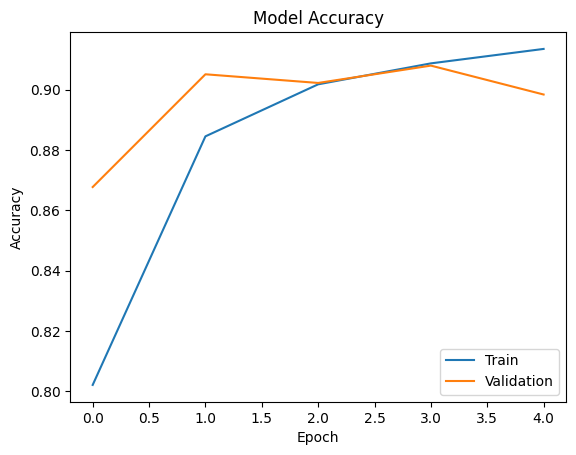

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

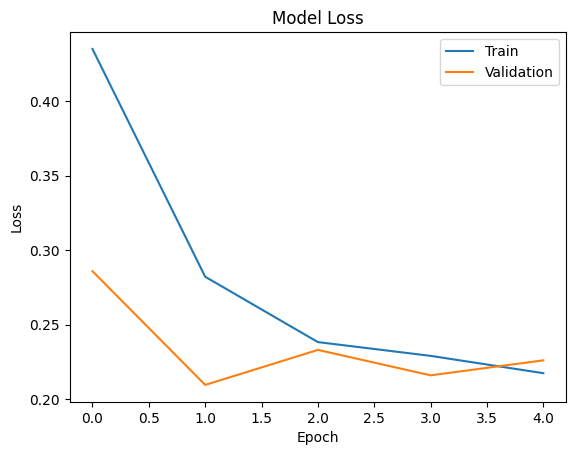

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9054 - loss: 0.3005
Test Accuracy: 0.9054487347602844


In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/pneumonia_model.h5"))

True


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/pneumonia_model.h5", compile=False)

# ✅ This automatically builds model
dummy = np.zeros((1, 224, 224, 3))
model.predict(dummy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


array([[0.5]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Raw prediction: 0.4970889


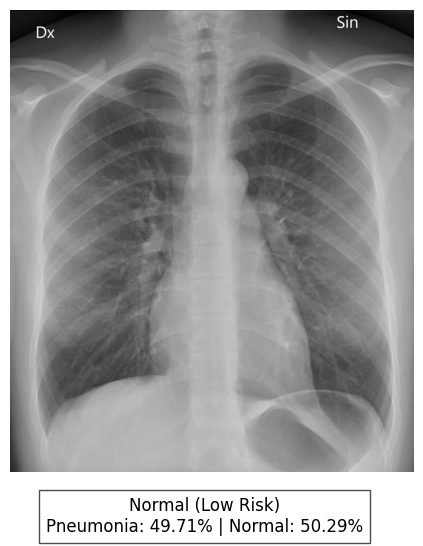

In [ ]:
# ================== IMPORTS ==================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ================== LOAD MODEL ==================
model = load_model("/content/drive/MyDrive/pneumonia_model.h5")

# ================== PREPROCESS FUNCTION ==================
def preprocess_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        raise ValueError("Image not found. Check the path.")

    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

# ================== PREDICTION FUNCTION ==================
def predict_disease(img_path):
    img = preprocess_image(img_path)

    prediction = model.predict(img)[0][0]
    print("Raw prediction:", prediction)

    pneumonia_percent = prediction * 100
    normal_percent = (1 - prediction) * 100

    # ================== 3-LEVEL CLASSIFICATION ==================
    if prediction > 0.4 and prediction < 0.5:
        label = "Normal"
        severity = "Low Risk"
    elif prediction > 0.5 and prediction < 0.7:
        label = "Pneumonia"
        severity = "Moderate Risk"
    else:
        label = "Pneumonia"
        severity = "High Risk"

    return label, severity, pneumonia_percent, normal_percent

# ================== IMAGE PATH ==================
img_path = "/content/Xray.jpg"

# ================== PREDICTION ==================
label, severity, pneumonia_p, normal_p = predict_disease(img_path)

# ================== DISPLAY IMAGE ==================
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')

# ================== TEXT BELOW IMAGE ==================
plt.figtext(
    0.5, 0.01,
    f"{label} ({severity})\n"
    f"Pneumonia: {pneumonia_p:.2f}% | Normal: {normal_p:.2f}%",
    ha="center",
    fontsize=12,
    bbox={"facecolor":"white", "alpha":0.7, "pad":5}
)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Raw prediction: 0.5002355


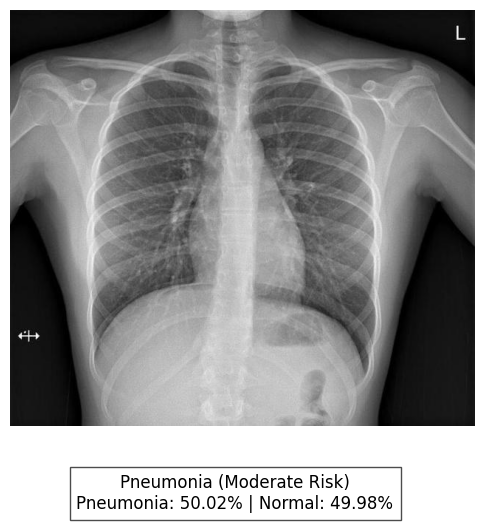

In [ ]:
# ================== IMPORTS ==================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ================== LOAD MODEL ==================
model = load_model("/content/drive/MyDrive/pneumonia_model.h5")

# ================== PREPROCESS FUNCTION ==================
def preprocess_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        raise ValueError("Image not found. Check the path.")

    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

# ================== PREDICTION FUNCTION ==================
def predict_disease(img_path):
    img = preprocess_image(img_path)

    prediction = model.predict(img)[0][0]
    print("Raw prediction:", prediction)

    pneumonia_percent = prediction * 100
    normal_percent = (1 - prediction) * 100

    # ================== 3-LEVEL CLASSIFICATION ==================
    if prediction > 0.4 and prediction < 0.5:
        label = "Normal"
        severity = "Low Risk"
    elif prediction > 0.5 and prediction < 0.7:
        label = "Pneumonia"
        severity = "Moderate Risk"
    else:
        label = "Pneumonia"
        severity = "High Risk"

    return label, severity, pneumonia_percent, normal_percent

# ================== IMAGE PATH ==================
img_path = "/content/normal2.jpeg"

# ================== PREDICTION ==================
label, severity, pneumonia_p, normal_p = predict_disease(img_path)

# ================== DISPLAY IMAGE ==================
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')

# ================== TEXT BELOW IMAGE ==================
plt.figtext(
    0.5, 0.01,
    f"{label} ({severity})\n"
    f"Pneumonia: {pneumonia_p:.2f}% | Normal: {normal_p:.2f}%",
    ha="center",
    fontsize=12,
    bbox={"facecolor":"white", "alpha":0.7, "pad":5}
)

plt.show()

In [ ]:
import numpy as np

# Make predictions on the test set
y_pred = model.predict(test_generator)

# Convert probabilities to binary class labels (0 or 1)
y_pred_classes = (y_pred > 0.5).astype(int)

print(np.unique(y_pred_classes, return_counts=True))

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
(array([0, 1]), array([599,  25]))


In [ ]:
prediction = model.predict(preprocess_image(img_path))[0][0]
print("Raw prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Raw prediction: 0.49506095


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,091 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
last_conv_layer = "your_last_conv_layer_name"

In [ ]:
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


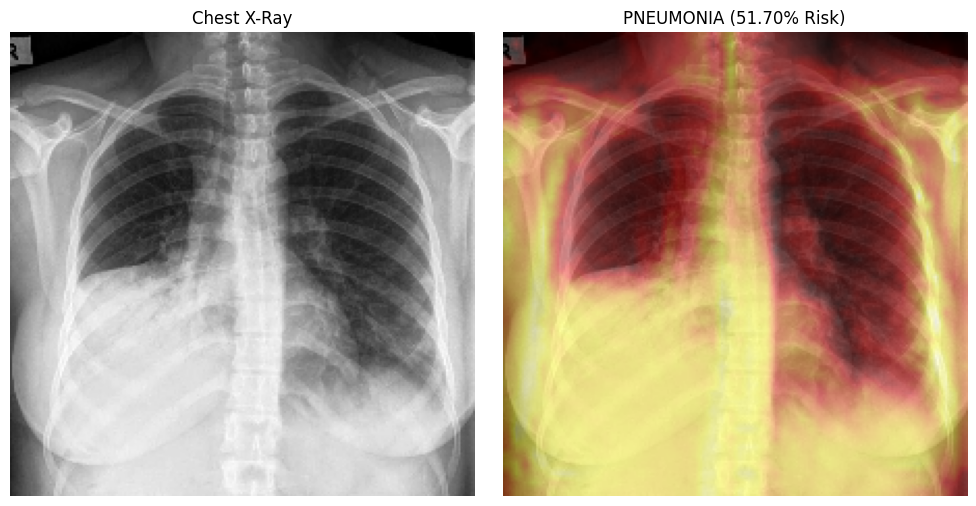

Final Result: PNEUMONIA
Risk Level: 51.70%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

# ================== LOAD MODEL ==================
model = load_model("/content/drive/MyDrive/pneumonia_model.h5")
IMG_SIZE = 224

# Force build model to infer input_shape correctly
if model.input_shape[-1] == 1:
    model(np.zeros((1,224,224,1)))
else:
    model(np.zeros((1,224,224,3)))

# ================== PREPROCESS ==================
def preprocess_image(path):
    # Use model.input_shape to determine if grayscale or RGB
    if model.input_shape[-1] == 1:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Image not found at {path}")
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_norm = img / 255.0
        img_input = np.expand_dims(img_norm, axis=(0,-1)) # Add channel dim for grayscale
    else:
        # Model expects 3 channels
        img = cv2.imread(path) # Reads as BGR (3 channels)
        if img is None:
            raise FileNotFoundError(f"Image not found at {path}")
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_norm = img / 255.0
        img_input = np.expand_dims(img_norm, axis=0) # Adds batch dimension, (1, 224, 224, 3)
    return img, img_input

# ================== LAST CONV LAYER ==================
last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break

# ================== GRAD-CAM ==================
def gradcam(model, img_array):
    # Create a symbolic input tensor for the Grad-CAM model
    # Use model.input_shape to ensure correctness, skipping batch dimension
    input_tensor_for_gradcam = tf.keras.Input(shape=model.input_shape[1:])

    # Pass the symbolic input through the model to get its symbolic output.
    x = input_tensor_for_gradcam
    conv_layer_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv:
            conv_layer_output = x
    model_output_tensor = x # This will be the output of the last layer traversed

    # Ensure conv_layer_output is found
    if conv_layer_output is None:
        raise ValueError(f"Last convolutional layer '{last_conv}' not found in the model.")

    grad_model = tf.keras.models.Model(
        inputs=input_tensor_for_gradcam,
        outputs=[conv_layer_output, model_output_tensor]
    )

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        conv_out, preds = grad_model(inputs)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    if tf.reduce_max(heatmap) != 0:
        heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

# ================== RUN ==================
def run(path):

    img, img_array = preprocess_image(path)

    prob = model.predict(img_array)[0][0]
    label = "PNEUMONIA" if prob > 0.5 else "NORMAL"
    conf = prob*100 if prob > 0.5 else (1-prob)*100

    # ================== GRAD-CAM ==================
    heatmap = gradcam(model, img_array)
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

    # Normalize
    heatmap = np.uint8(255 * heatmap)

    # ☀️ Apply RED-YELLOW colormap (NO BLUE)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_HOT)

    # Prepare original image for overlay and display
    # img is the original image read by cv2.imread, potentially 1 or 3 channels
    if len(img.shape) == 2: # Grayscale image
        img_display_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) # Convert to 3 channel BGR for overlay
    else: # Color image (already BGR from cv2.imread)
        img_display_bgr = img

    # Resize to match (ensure consistent size before overlay)
    img_display_bgr = cv2.resize(img_display_bgr, (IMG_SIZE, IMG_SIZE))

    # ================== OVERLAY ==================
    overlay = cv2.addWeighted(img_display_bgr, 0.6, heatmap_color, 0.4, 0)

    # ================== DISPLAY ==================
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    # Display original image (grayscale if it was loaded as such, or RGB if color)
    if len(img.shape) == 2: # Grayscale image
        plt.imshow(img, cmap='gray')
    else: # Color image
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Chest X-Ray")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"{label} ({conf:.2f}% Risk)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("Final Result:", label)
    print("Risk Level:", f"{conf:.2f}%")

# ================== RUN ==================
run("demo2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


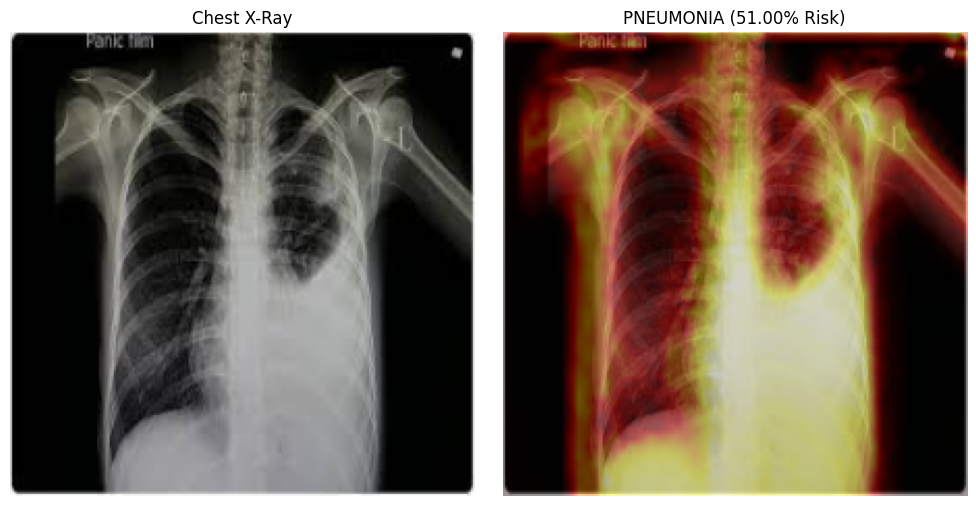

Final Result: PNEUMONIA
Risk Level: 51.00%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

# ================== LOAD MODEL ==================
model = load_model("/content/drive/MyDrive/pneumonia_model.h5")
IMG_SIZE = 224

# Force build model to infer input_shape correctly
if model.input_shape[-1] == 1:
    model(np.zeros((1,224,224,1)))
else:
    model(np.zeros((1,224,224,3)))

# ================== PREPROCESS ==================
def preprocess_image(path):
    # Use model.input_shape to determine if grayscale or RGB
    if model.input_shape[-1] == 1:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Image not found at {path}")
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_norm = img / 255.0
        img_input = np.expand_dims(img_norm, axis=(0,-1)) # Add channel dim for grayscale
    else:
        # Model expects 3 channels
        img = cv2.imread(path) # Reads as BGR (3 channels)
        if img is None:
            raise FileNotFoundError(f"Image not found at {path}")
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_norm = img / 255.0
        img_input = np.expand_dims(img_norm, axis=0) # Adds batch dimension, (1, 224, 224, 3)
    return img, img_input

# ================== LAST CONV LAYER ==================
last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break

# ================== GRAD-CAM ==================
def gradcam(model, img_array):
    # Create a symbolic input tensor for the Grad-CAM model
    # Use model.input_shape to ensure correctness, skipping batch dimension
    input_tensor_for_gradcam = tf.keras.Input(shape=model.input_shape[1:])

    # Pass the symbolic input through the model to get its symbolic output.
    x = input_tensor_for_gradcam
    conv_layer_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv:
            conv_layer_output = x
    model_output_tensor = x # This will be the output of the last layer traversed

    # Ensure conv_layer_output is found
    if conv_layer_output is None:
        raise ValueError(f"Last convolutional layer '{last_conv}' not found in the model.")

    grad_model = tf.keras.models.Model(
        inputs=input_tensor_for_gradcam,
        outputs=[conv_layer_output, model_output_tensor]
    )

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        conv_out, preds = grad_model(inputs)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    if tf.reduce_max(heatmap) != 0:
        heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

# ================== RUN ==================
def run(path):

    img, img_array = preprocess_image(path)

    prob = model.predict(img_array)[0][0]
    label = "PNEUMONIA" if prob > 0.5 else "NORMAL"
    conf = prob*100 if prob > 0.5 else (1-prob)*100

    # ================== GRAD-CAM ==================
    heatmap = gradcam(model, img_array)
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

    # Normalize
    heatmap = np.uint8(255 * heatmap)

    # ☀️ Apply RED-YELLOW colormap (NO BLUE)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_HOT)

    # Prepare original image for overlay and display
    # img is the original image read by cv2.imread, potentially 1 or 3 channels
    if len(img.shape) == 2: # Grayscale image
        img_display_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) # Convert to 3 channel BGR for overlay
    else: # Color image (already BGR from cv2.imread)
        img_display_bgr = img

    # Resize to match (ensure consistent size before overlay)
    img_display_bgr = cv2.resize(img_display_bgr, (IMG_SIZE, IMG_SIZE))

    # ================== OVERLAY ==================
    overlay = cv2.addWeighted(img_display_bgr, 0.6, heatmap_color, 0.4, 0)

    # ================== DISPLAY ==================
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    # Display original image (grayscale if it was loaded as such, or RGB if color)
    if len(img.shape) == 2: # Grayscale image
        plt.imshow(img, cmap='gray')
    else: # Color image
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Chest X-Ray")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"{label} ({conf:.2f}% Risk)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("Final Result:", label)
    print("Risk Level:", f"{conf:.2f}%")

# ================== RUN ==================
run("/content/demo.jpg")